In [1]:
from pathlib import Path
from textalloc import allocate
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [2]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))
# input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_population_bins_beta_zero_pop_0.25.yml").read_text(encoding="utf-8"))


population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]
public_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][0]
private_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][1]

print(f"Population scale: {population_scale_from_input_yml}")
print(f"Starting date: {starting_date}")
print(f"Birth rate: {birth_rate_from_config}")
print(f"Public percentage: {public_pct}")
print(f"Private percentage: {private_pct}")

# 1) Use the original dict
country_dict = {
    "population_scale": population_scale_from_input_yml,
    }
country_json = json.dumps(country_dict, ensure_ascii=False)
# 3) Attribute-style access (SimpleNamespace)
from types import SimpleNamespace
country = json.loads(country_json, object_hook=lambda d: SimpleNamespace(**d))

exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print("\ndata_path:", data_path)
print("output_path:", output_path)
print("analysis_path:", analysis_path)

Population scale: 0.25
Starting date: 2011/1/1
Birth rate: 0.0335
Public percentage: 0.445
Private percentage: 0.555

data_path: DATA
output_path: validation_runs/validation_2_0.25_population_scale_one_pattern_20_replicates/output
analysis_path: validation_runs/validation_2_0.25_population_scale_one_pattern_20_replicates/analysis


## PfPR

In [3]:
output_path_obj = Path(output_path)
if not output_path_obj.exists() or not output_path_obj.is_dir():
    raise NotADirectoryError(f"Path {output_path} is not a valid directory.")
db_files = list(output_path_obj.glob("*.db"))
if len(db_files) == 0:
    raise FileNotFoundError(f"No .db files found in directory {output_path}.")

agg_population = pd.DataFrame(columns=["monthly_data_id", "unit_id", "population"])
agg_treatment = pd.DataFrame(columns=["monthly_data_id", "unit_id", "treatments"])
agg_clinical_episodes = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes"])
agg_prevalence_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_2to10"])
agg_clinical_episodes_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"])
agg_prevalence_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_under5"])
agg_clinical_episodes_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_under5"])

rep = 0
for file in output_path_obj.glob("*.db"):
    data = get_table(file, "monthly_site_data_district")
    clinical_episodes_2_to_10 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].copy()
    clinical_episodes_2_to_10["clinical_episodes_2_to_10"] = clinical_episodes_2_to_10[
        [
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].sum(axis=1)
    clinical_episodes_under_5 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].copy()
    clinical_episodes_under_5["clinical_episodes_under5"] = clinical_episodes_under_5[
        [
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].sum(axis=1)
    
    # Add a column to the agg_* data frames from data
    try:
        agg_population = agg_population.merge(
            data[["monthly_data_id", "unit_id", "population"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_treatment = agg_treatment.merge(
            data[["monthly_data_id", "unit_id", "treatments"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes = agg_clinical_episodes.merge(
            data[["monthly_data_id", "unit_id", "clinical_episodes"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_2_to_10 = agg_prevalence_2_to_10.merge(
            data[["monthly_data_id", "unit_id", "pfpr_2to10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        
        agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.merge(
            clinical_episodes_2_to_10[["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_under_5 = agg_prevalence_under_5.merge(
            data[["monthly_data_id", "unit_id", "pfpr_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.merge(
            clinical_episodes_under_5[["monthly_data_id", "unit_id", "clinical_episodes_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
    except Exception as e:
        error(f"Error processing replicate {rep}: {e}")
    rep += 1
    
agg_population = agg_population.drop(columns=["population"])
agg_treatment = agg_treatment.drop(columns=["treatments"])
agg_clinical_episodes = agg_clinical_episodes.drop(columns=["clinical_episodes"])
agg_prevalence_2_to_10 = agg_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.drop(columns=["clinical_episodes_2_to_10"])
agg_prevalence_under_5 = agg_prevalence_under_5.drop(columns=["pfpr_under5"])
agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.drop(columns=["clinical_episodes_under5"])

agg_prevalence_2_to_10.to_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv", index=False)
agg_clinical_episodes_2_to_10.to_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv", index=False)
agg_prevalence_under_5.to_csv(f"{analysis_path}/agg_prevalence_under_5.csv", index=False)
agg_clinical_episodes_under_5.to_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv", index=False)
agg_population.to_csv(f"{analysis_path}/agg_population.csv", index=False)
agg_treatment.to_csv(f"{analysis_path}/agg_treatment.csv", index=False)
agg_clinical_episodes.to_csv(f"{analysis_path}/agg_clinical_episodes.csv", index=False)

In [4]:
agg_clinical_episodes.tail(24)
agg_clinical_episodes = agg_clinical_episodes.sort_values("unit_id", ascending=False).reset_index(drop=True)
unit_id_to_inspect = 6
agg_clinical_episodes.loc[
    agg_clinical_episodes["unit_id"] == unit_id_to_inspect
].sort_values("monthly_data_id")
agg_clinical_episodes.tail(24)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
468,22,1,90437.0,91576.0,90723.0,90889.0,91286.0,90692,90657.0,90317.0,...,90720.0,90594.0,91351.0,90463.0,NaN,90452.0,91074.0,91034.0,90645.0,NaN
469,21,1,99621.0,100722.0,100247.0,99558.0,100248.0,99857,99711.0,99775.0,...,100365.0,99692.0,100150.0,99804.0,NaN,99954.0,99951.0,99325.0,99345.0,NaN
470,20,1,106476.0,108248.0,107459.0,106772.0,106678.0,106476,106858.0,107234.0,...,107308.0,107237.0,107296.0,106718.0,NaN,107019.0,107726.0,106307.0,106531.0,NaN
471,15,1,162910.0,164341.0,164726.0,163248.0,163303.0,162579,162847.0,163703.0,...,163389.0,162906.0,162844.0,162828.0,NaN,162671.0,163924.0,163561.0,163575.0,NaN
472,17,1,134474.0,134894.0,134580.0,133262.0,135226.0,134160,134503.0,134335.0,...,134955.0,134386.0,134241.0,134383.0,NaN,133936.0,135158.0,134336.0,134324.0,NaN
473,16,1,154041.0,156146.0,155566.0,153771.0,154938.0,154266,155972.0,155523.0,...,155156.0,154355.0,155374.0,153742.0,NaN,154315.0,155119.0,154575.0,154171.0,NaN
474,67,1,66205.0,66134.0,66352.0,65882.0,66273.0,65896,65407.0,66413.0,...,65417.0,66363.0,65775.0,66126.0,NaN,66568.0,66216.0,66064.0,66088.0,NaN
475,68,1,68403.0,68870.0,68442.0,68052.0,68873.0,68495,68216.0,68959.0,...,67918.0,68929.0,68232.0,68211.0,NaN,68543.0,68679.0,68631.0,68725.0,NaN
476,9,1,492319.0,493438.0,494340.0,492689.0,492243.0,492500,493329.0,493538.0,...,492404.0,492032.0,493229.0,492007.0,NaN,492506.0,492885.0,491319.0,492585.0,NaN
477,8,1,612260.0,612760.0,614058.0,611252.0,613166.0,612086,612572.0,613681.0,...,614161.0,611765.0,612031.0,611473.0,NaN,612006.0,612944.0,610248.0,612623.0,NaN


In [5]:
months = np.sort(agg_clinical_episodes["monthly_data_id"].unique())
end_month = int(months[-1]) + 1
start_month = end_month - 12

In [6]:
agg_test = pd.DataFrame(columns=["monthly_data_id", "unit_id"])

In [7]:
data_test = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes",
            "population",
            "treatments"
        ]    
    ].copy()

In [8]:
agg_test

,monthly_data_id,unit_id


In [9]:
data_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1414496,0
1,1,2,0,877087,0
2,1,3,0,718843,0
3,1,4,0,608423,0
4,1,5,0,1041247,0
5,1,6,0,715620,0
6,2,1,561206,1417518,263578
7,2,2,374212,874461,140404
8,2,3,253615,715170,117850
9,2,4,245952,611574,82433


In [10]:
agg_test = agg_test.merge(
    data[["monthly_data_id", "unit_id", "clinical_episodes","population","treatments"]].copy(),
    how="outer",
    on=["monthly_data_id", "unit_id"],
    suffixes=("", f"_{validation_replicates}"),
)

In [11]:
agg_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1414496,0
1,1,2,0,877087,0
2,1,3,0,718843,0
3,1,4,0,608423,0
4,1,5,0,1041247,0
5,1,6,0,715620,0
6,2,1,561206,1417518,263578
7,2,2,374212,874461,140404
8,2,3,253615,715170,117850
9,2,4,245952,611574,82433


In [12]:
agg_test_at_calib = agg_test.loc[agg_test["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()

In [13]:
g = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"]

In [14]:
for unit_id, vals in g:
    print("unit_id:", unit_id)
    print(vals)
    print()

In [15]:
agg_test_at_calib_mean_by_location = pd.DataFrame()
agg_test_at_calib_mean_by_location["clinical_episodes_mean"] = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"].sum()
agg_test_at_calib_mean_by_location["population_mean"] = agg_test_at_calib.copy().groupby("unit_id")["population"].mean()
agg_test_at_calib_mean_by_location["treatments_mean"] = agg_test_at_calib.copy().groupby("unit_id")["treatments"].sum()

In [16]:
agg_test_at_calib_mean_by_location

,clinical_episodes_mean,population_mean,treatments_mean


In [17]:
agg_test_at_calib_mean_by_location.sum(axis=0)

clinical_episodes_mean    0.0
population_mean           0.0
treatments_mean           0.0
dtype: float64

In [18]:
agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [19]:
agg_clinical_episodes.tail(6)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
486,82,1,NaN,NaN,NaN,NaN,NaN,67269,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
487,82,2,NaN,NaN,NaN,NaN,NaN,41479,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
488,82,3,NaN,NaN,NaN,NaN,NaN,33442,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
489,82,4,NaN,NaN,NaN,NaN,NaN,28518,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
490,82,5,NaN,NaN,NaN,NaN,NaN,56914,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
491,82,6,NaN,NaN,NaN,NaN,NaN,33870,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
data_at_calib = agg_clinical_episodes.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()
data_at_calib

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
420,71,1,68708.0,68907.0,69052.0,68350.0,68867.0,68651,68434.0,68554.0,...,68002.0,68940.0,68763.0,68740.0,NaN,69025.0,69128.0,68474.0,69196.0,NaN
421,71,2,42918.0,43013.0,42357.0,42298.0,42933.0,42509,42657.0,42462.0,...,42578.0,42542.0,42241.0,42912.0,NaN,42236.0,42832.0,42924.0,42054.0,NaN
422,71,3,33917.0,34341.0,34695.0,34314.0,34481.0,34228,34099.0,34777.0,...,34329.0,34173.0,34215.0,34158.0,NaN,34043.0,33863.0,34312.0,33985.0,NaN
423,71,4,29480.0,29275.0,29028.0,28987.0,29155.0,29243,29283.0,29333.0,...,29137.0,29403.0,28799.0,29603.0,NaN,28955.0,28881.0,29315.0,28994.0,NaN
424,71,5,57623.0,57391.0,58180.0,57408.0,58376.0,58876,57642.0,57642.0,...,57307.0,57663.0,57101.0,57912.0,NaN,57657.0,57773.0,58452.0,57600.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,82,2,NaN,NaN,NaN,NaN,NaN,41479,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
488,82,3,NaN,NaN,NaN,NaN,NaN,33442,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
489,82,4,NaN,NaN,NaN,NaN,NaN,28518,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
490,82,5,NaN,NaN,NaN,NaN,NaN,56914,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
data_at_calib_sum_1_year = data_at_calib.groupby("unit_id").sum().reset_index()
data_at_calib_sum_1_year

,unit_id,monthly_data_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
0,1,918,135172.0,405894.0,135643.0,272483.0,405503.0,812757,271876.0,68554.0,...,271772.0,336746.0,335979.0,204495.0,0.0,611212.0,69128.0,334433.0,205689.0,0.0
1,2,918,84326.0,251267.0,83308.0,168381.0,251532.0,502178,168328.0,42462.0,...,168888.0,207667.0,207127.0,127402.0,0.0,373374.0,42832.0,208733.0,124861.0,0.0
2,3,918,67061.0,201385.0,68172.0,136713.0,203285.0,405125,135655.0,34777.0,...,136427.0,167485.0,167636.0,102237.0,0.0,301563.0,33863.0,167723.0,100890.0,0.0
3,4,918,57801.0,171794.0,57245.0,116622.0,171521.0,345411,116445.0,29333.0,...,116035.0,143773.0,142179.0,87353.0,0.0,255923.0,28881.0,142834.0,86348.0,0.0
4,5,918,113452.0,340351.0,114624.0,230592.0,342426.0,691475,229973.0,57642.0,...,228413.0,281439.0,281783.0,171729.0,0.0,511083.0,57773.0,284333.0,171607.0,0.0
5,6,918,68373.0,203929.0,68390.0,137294.0,203138.0,407456,137615.0,34953.0,...,138298.0,168222.0,170669.0,103035.0,0.0,305538.0,34890.0,169925.0,103156.0,0.0


In [22]:
data_at_calib_mean_all_rep_1_year = data_at_calib_sum_1_year.copy().drop(columns=["monthly_data_id"]).mean(axis=1)
data_at_calib_mean_all_rep_1_year

0    264197.476190
1    163138.761905
2    131677.285714
3    112159.428571
4    222620.952381
5    132986.190476
dtype: float64

In [23]:
data_at_calib_mean_all_rep_1_year.sum()

np.float64(1026780.0952380951)

In [24]:
mean_treatment = (
    agg_treatment.loc[agg_treatment["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_treatment = mean_treatment.drop(columns=["monthly_data_id"])
# mean_treatment = mean_treatment.drop(columns=["clinical_episodes"])
mean_treatment["mean"] = mean_treatment.mean(axis=1)
mean_treatment["std"] = mean_treatment.std(axis=1)

mean_clinical_episodes = (
    agg_clinical_episodes.loc[agg_clinical_episodes["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_clinical_episodes = mean_clinical_episodes.drop(columns=["monthly_data_id"])
# mean_clinical_episodes = mean_clinical_episodes.drop(columns=["clinical_episodes"])
mean_clinical_episodes["mean"] = mean_clinical_episodes.mean(axis=1)
mean_clinical_episodes["std"] = mean_clinical_episodes.std(axis=1)

mean_population = (
    agg_population.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_population = mean_population.drop(columns=["monthly_data_id"])
# mean_population = mean_population.drop(columns=["population"])
mean_population["mean"] = mean_population.mean(axis=1)
mean_population["std"] = mean_population.std(axis=1)

mean_prevalence_2_to_10 = (
    agg_prevalence_2_to_10.loc[
        agg_prevalence_2_to_10["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["monthly_data_id"])
# mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
mean_prevalence_2_to_10["mean"] = mean_prevalence_2_to_10.mean(axis=1)
mean_prevalence_2_to_10["std"] = mean_prevalence_2_to_10.std(axis=1)

mean_prevalence_under_5 = (
    agg_prevalence_under_5.loc[
        agg_prevalence_under_5["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_under_5 = mean_prevalence_under_5.drop(columns=["monthly_data_id"])
# mean_prevalence_under_5 = mean_prevalence_under_5.drop(columns=["pfpr_under5"])
mean_prevalence_under_5["mean"] = mean_prevalence_under_5.mean(axis=1)
mean_prevalence_under_5["std"] = mean_prevalence_under_5.std(axis=1)

mean_clinical_episodes.to_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment.to_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10.to_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5.to_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population.to_csv(f"{analysis_path}/mean_population.csv")

In [25]:
mean_prevalence_2_to_10

,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,pfpr_2to10_9,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,28.374165,28.416842,28.485878,28.360295,28.410247,28.428858,28.285809,28.301818,28.395895,28.498541,...,28.382456,28.396081,NaN,28.456854,28.443323,28.397014,28.399462,NaN,28.398423,0.053972
2,30.546091,30.681974,30.642313,30.568005,30.589179,30.686339,30.537096,30.489885,30.600826,30.615164,...,30.675056,30.621472,NaN,30.547654,30.665541,30.682304,30.560096,NaN,30.607850,0.057828
3,25.005207,24.990600,25.128664,25.025475,25.117537,25.002017,24.990879,25.114344,24.993946,25.099715,...,25.067359,25.113944,NaN,24.978426,24.955373,25.010953,24.904998,NaN,25.026656,0.062788
4,28.520892,28.459592,28.291520,28.515382,28.427074,28.420234,28.391532,28.584667,28.512694,28.361674,...,28.511162,28.375724,NaN,28.294454,28.313925,28.465375,28.467237,NaN,28.440310,0.084117
5,18.748726,18.813468,18.861521,18.828824,18.910473,18.900708,18.873669,18.918233,18.857143,18.874813,...,18.834097,18.828515,NaN,18.853834,18.753677,18.869247,18.889662,NaN,18.847821,0.046615
6,27.729312,27.692546,27.833768,27.550192,27.745789,27.666183,27.790347,27.648066,27.655401,27.795276,...,27.755697,27.699241,NaN,27.776158,27.801363,27.781973,27.746691,NaN,27.711981,0.086446


In [26]:
mean_population

,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,population_9,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1544325.5,1.549372e+06,1544095.0,1546009.50,1.549347e+06,1.553809e+06,1546285.50,1543501.0,1548448.6,1546600.8,...,1548303.0,1.545704e+06,NaN,1.551931e+06,1543675.0,1547264.8,1.546049e+06,NaN,1.547123e+06,2725.281421
2,937028.5,9.401573e+05,937684.0,937943.50,9.392592e+05,9.426479e+05,938164.25,936793.0,938298.6,938270.6,...,938790.4,9.373520e+05,NaN,9.406547e+05,937209.0,938999.2,9.372743e+05,NaN,9.385321e+05,1418.929236
3,781841.0,7.837543e+05,781924.0,783071.50,7.840093e+05,7.868408e+05,782164.50,780645.0,782392.2,782637.8,...,783224.8,7.818297e+05,NaN,7.849628e+05,780956.0,783218.4,7.825057e+05,NaN,7.828724e+05,1396.045594
4,652030.0,6.542772e+05,652899.5,653339.25,6.542525e+05,6.552800e+05,653103.50,651939.0,653004.8,653461.6,...,653255.0,6.528130e+05,NaN,6.551808e+05,652276.0,653112.4,6.526207e+05,NaN,6.532766e+05,937.372166
5,1127032.0,1.129264e+06,1126493.5,1127727.50,1.129633e+06,1.135441e+06,1128611.25,1124659.0,1128952.8,1128915.0,...,1128515.6,1.128213e+06,NaN,1.131411e+06,1126547.0,1128539.6,1.127414e+06,NaN,1.128559e+06,2181.840601
6,759463.0,7.613553e+05,759975.5,760998.75,7.614610e+05,7.636524e+05,760548.25,759595.0,760907.0,761016.0,...,761626.0,7.602353e+05,NaN,7.621329e+05,759774.0,761405.0,7.606500e+05,NaN,7.609199e+05,972.043353


In [27]:
mean_clinical_episodes

,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,clinical_episodes_9,...,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,135172.0,405894.0,135643.0,272483.0,405503.0,812757,271876.0,68554.0,335080.0,335730.0,...,335979.0,204495.0,0.0,611212.0,69128.0,334433.0,205689.0,0.0,277407.30,192309.315537
2,84326.0,251267.0,83308.0,168381.0,251532.0,502178,168328.0,42462.0,206777.0,206469.0,...,207127.0,127402.0,0.0,373374.0,42832.0,208733.0,124861.0,0.0,171295.60,118501.767351
3,67061.0,201385.0,68172.0,136713.0,203285.0,405125,135655.0,34777.0,166489.0,168734.0,...,167636.0,102237.0,0.0,301563.0,33863.0,167723.0,100890.0,0.0,138261.00,95638.886376
4,57801.0,171794.0,57245.0,116622.0,171521.0,345411,116445.0,29333.0,142896.0,142950.0,...,142179.0,87353.0,0.0,255923.0,28881.0,142834.0,86348.0,0.0,117767.20,81400.253616
5,113452.0,340351.0,114624.0,230592.0,342426.0,691475,229973.0,57642.0,282289.0,284051.0,...,281783.0,171729.0,0.0,511083.0,57773.0,284333.0,171607.0,0.0,233751.75,162682.211455
6,68373.0,203929.0,68390.0,137294.0,203138.0,407456,137615.0,34953.0,168477.0,169346.0,...,170669.0,103035.0,0.0,305538.0,34890.0,169925.0,103156.0,0.0,139635.20,96330.708542


In [28]:
incidence_per_1000_sanity_check = mean_clinical_episodes["mean"] / mean_population["mean"] * 1000
incidence_per_1000_sanity_check

unit_id
1    179.305286
2    182.514368
3    176.607317
4    180.271579
5    207.124078
6    183.508410
Name: mean, dtype: float64

In [29]:
mean_treatment

,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,treatments_9,...,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,82205.0,247165.0,82448.0,165753.0,247118.0,493717,165352.0,41793.0,203733.0,204081.0,...,204618.0,124435.0,0.0,371843.0,42127.0,203256.0,125117.0,0.0,168737.00,116914.506304
2,41622.0,124114.0,41083.0,82925.0,124095.0,248019,83090.0,21029.0,101435.0,101846.0,...,102148.0,62930.0,0.0,184318.0,21030.0,102826.0,61637.0,0.0,84521.65,58503.844470
3,38800.0,117074.0,39629.0,79562.0,118463.0,234716,78731.0,20077.0,96308.0,97977.0,...,96850.0,59324.0,0.0,175187.0,19571.0,97365.0,58765.0,0.0,80209.00,55479.905077
4,25320.0,74923.0,25062.0,50934.0,75204.0,151043,50889.0,12789.0,62489.0,62494.0,...,62102.0,38234.0,0.0,112019.0,12608.0,62814.0,37439.0,0.0,51479.00,35610.650275
5,42952.0,129232.0,43553.0,86989.0,130077.0,262292,87156.0,21897.0,106946.0,107798.0,...,106675.0,65144.0,0.0,193431.0,21756.0,108207.0,65295.0,0.0,88641.70,61691.322768
6,26580.0,78847.0,26587.0,52795.0,78255.0,156368,53043.0,13447.0,65003.0,65190.0,...,65822.0,39377.0,0.0,117259.0,13470.0,65288.0,39897.0,0.0,53750.75,36981.383330


In [30]:
total_mean_clinical_episodes = mean_clinical_episodes["mean"].sum()
total_mean_treatment = mean_treatment["mean"].sum()
total_mean_population = mean_population["mean"].sum()

print(f"Total mean clinical episodes (all districts): {total_mean_clinical_episodes:,.0f}")
print(f"Total mean treatments (all districts): {total_mean_treatment:,.0f}")
print(f"Total mean population (all districts): {total_mean_population:,.0f}")

Total mean clinical episodes (all districts): 1,078,118
Total mean treatments (all districts): 527,339
Total mean population (all districts): 5,811,283


In [31]:
mean_clinical_episodes = pd.read_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment = pd.read_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5 = pd.read_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population = pd.read_csv(f"{analysis_path}/mean_population.csv")

In [32]:
mean_prevalence_2_to_10

,unit_id,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
0,1,28.374165,28.416842,28.485878,28.360295,28.410247,28.428858,28.285809,28.301818,28.395895,...,28.382456,28.396081,NaN,28.456854,28.443323,28.397014,28.399462,NaN,28.398423,0.053972
1,2,30.546091,30.681974,30.642313,30.568005,30.589179,30.686339,30.537096,30.489885,30.600826,...,30.675056,30.621472,NaN,30.547654,30.665541,30.682304,30.560096,NaN,30.607850,0.057828
2,3,25.005207,24.990600,25.128664,25.025475,25.117537,25.002017,24.990879,25.114344,24.993946,...,25.067359,25.113944,NaN,24.978426,24.955373,25.010953,24.904998,NaN,25.026656,0.062788
3,4,28.520892,28.459592,28.291520,28.515382,28.427074,28.420234,28.391532,28.584667,28.512694,...,28.511162,28.375724,NaN,28.294454,28.313925,28.465375,28.467237,NaN,28.440310,0.084117
4,5,18.748726,18.813468,18.861521,18.828824,18.910473,18.900708,18.873669,18.918233,18.857143,...,18.834097,18.828515,NaN,18.853834,18.753677,18.869247,18.889662,NaN,18.847821,0.046615
5,6,27.729312,27.692546,27.833768,27.550192,27.745789,27.666183,27.790347,27.648066,27.655401,...,27.755697,27.699241,NaN,27.776158,27.801363,27.781973,27.746691,NaN,27.711981,0.086446


In [33]:
district_mapping = pd.read_csv(Path(data_path) / f"{country_code}_mapping.csv")
district_mapping.columns = ["district_name", "unit_id"]
district_mapping

,district_name,unit_id
0,Benue,7
1,Cross River,9
2,Ebonyi,11
3,Nassarawa,26
4,Plateau,32
5,Taraba,35


In [34]:
district_raster, district_metadata = read_raster(districts_raster_path)
prevalence_obs, prevalence_metadata = read_raster(pfpr_raster_path)
observed_incidence_per_district = pd.read_csv(f"{data_path}/Observed_Incidence_Per_District_{incidence_comparison_year}.csv")
old_to_new_district_id_mapping = pd.read_csv(f"{data_path}/{country_code}_district_seq1_mapping.csv")

prevalence_nodata = prevalence_metadata["NODATA_value"]
district_nodata = district_metadata["NODATA_value"]

valid_districts = district_raster[district_raster != district_nodata]
valid_prevalence = prevalence_obs[prevalence_obs != prevalence_nodata]

data_sim = pd.DataFrame({"unit_id": mean_prevalence_2_to_10.unit_id, 
                                "mean_2_to_10_sim": mean_prevalence_2_to_10["mean"],
                                "mean_population_sim": mean_population["mean"],
                                "mean_clinical_episodes_sim": mean_clinical_episodes["mean"],
                                "mean_treatment_sim": mean_treatment["mean"],
                                })
data_sim["mean_2_to_10_sim"] = data_sim["mean_2_to_10_sim"].div(100)
data_sim["mean_population_sim"] = data_sim["mean_population_sim"] / country.population_scale
# Get total public and private from public cases and percentage private over public
data_sim["mean_clinical_episodes_sim"] = data_sim["mean_clinical_episodes_sim"] / country.population_scale
data_sim["mean_treatment_sim"] = (data_sim["mean_treatment_sim"] / country.population_scale) * public_pct

# Map to new unit id
data_sim["unit_id"] = data_sim["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])

In [35]:
data_sim

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim
0,7,0.283984,6.188491e+06,1109629.2,300351.860
1,9,0.306079,3.754129e+06,685182.4,150448.537
2,11,0.250267,3.131490e+06,553044.0,142772.020
3,26,0.284403,2.613106e+06,471068.8,91632.620
4,32,0.188478,4.514236e+06,935007.0,157782.226
5,35,0.277120,3.043680e+06,558540.8,95676.335


In [36]:
prevalence_district_obs = pd.DataFrame({"unit_id": valid_districts.flatten(), "mean_2_to_10_obs": valid_prevalence.flatten()})
prevalence_district_mean_obs = prevalence_district_obs.groupby("unit_id")["mean_2_to_10_obs"].mean().to_frame()
pop_clinical_episodes_obs = pd.read_csv(f"{generated_data_path}/population_incidence_per_district.csv")

observed_incidence_per_district = observed_incidence_per_district.iloc[:-1]

compare_data = data_sim.merge(observed_incidence_per_district, left_on="unit_id", right_on="Region ID", how="outer")
compare_data = compare_data.merge(prevalence_district_mean_obs, left_on="unit_id", right_on="unit_id", how="outer")
compare_data.rename(columns={"Population (2021 target based on worldometers birth rate and wordpop raster counts)": "population_obs"}, inplace=True)
compare_data.rename(columns={"Total Cases 2021 from projected population and observed incidence": "annual_clinical_episodes_obs"}, inplace=True)
compare_data

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from rasters),Growth Rate (2019-2020),population_obs,annual_clinical_episodes_obs,mean_2_to_10_obs
0,7,0.283984,6.188491e+06,1109629.2,300351.860,Benue,7.0,257.2,5787706,6464378,1.116915,6601202,1697829,0.296162
1,9,0.306079,3.754129e+06,685182.4,150448.537,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327,1182153,0.333528
2,11,0.250267,3.131490e+06,553044.0,142772.020,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353832,1245948,0.266297
3,26,0.284403,2.613106e+06,471068.8,91632.620,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686,778632,0.289176
4,32,0.188478,4.514236e+06,935007.0,157782.226,Plateau,32.0,286.5,4400974,4758921,1.081334,4859648,1392289,0.218215
5,35,0.277120,3.043680e+06,558540.8,95676.335,Taraba,35.0,299.9,3331885,3274257,0.982704,3343560,1002734,0.290542


In [37]:
print(f"Total observed clinical episodes (all districts): {compare_data['annual_clinical_episodes_obs'].sum():.0f}")
print(f"Total observed population (all districts): {compare_data['population_obs'].sum():.0f}")

Total observed clinical episodes (all districts): 7299585
Total observed population (all districts): 25092255


### Multiply Sim Clinical Episodes by Treatment Access Rate and Public Sector for Comparision to Observed Data

In [38]:
print(f"Public treatment percentage: {public_pct * 100}%")

Public treatment percentage: 44.5%


In [39]:
compare_data["adjusted_mean_clinical_episodes_sim"] = compare_data["mean_clinical_episodes_sim"] * public_pct
compare_data[["adjusted_mean_clinical_episodes_sim", "mean_clinical_episodes_sim"]] 

,adjusted_mean_clinical_episodes_sim,mean_clinical_episodes_sim
0,493784.994,1109629.2
1,304906.168,685182.4
2,246104.580,553044.0
3,209625.616,471068.8
4,416078.115,935007.0
5,248550.656,558540.8


In [40]:
compare_data.to_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")

In [41]:
compare_data = pd.read_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")

In [42]:
# ======================================================
# Load data
# ======================================================
csv_path = f"{analysis_path}/compare_data_pfpr_pop_incidence.csv"
compare_data = pd.read_csv(csv_path)

# Optional style
# sns.set_style("whitegrid")

<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2071102/1739925926.py:68: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",


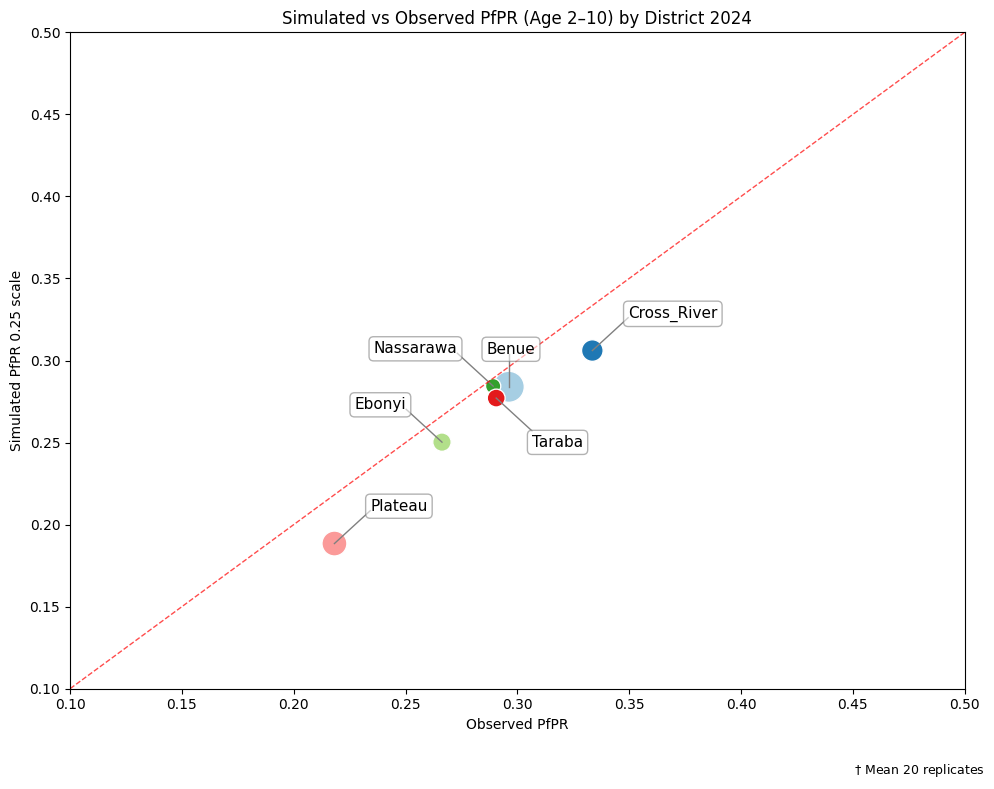

In [43]:
# ======================================================
# Figure 1: Simulated vs Observed PfPR by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d1 = compare_data[["mean_2_to_10_obs", "mean_2_to_10_sim", "State", "mean_population_sim"]].dropna(
    subset=["mean_2_to_10_obs", "mean_2_to_10_sim"]
)

sns.scatterplot(
    data=d1,
    x="mean_2_to_10_obs",
    y="mean_2_to_10_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

''' Use full range when trying to calibrate pipeline, narrow range yields better looking plots when finalized'''

# ax.set_xlim(0.0, 1.0)
# ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.1, 0.5)

span = min(ax.get_xlim()[1] - ax.get_xlim()[0], ax.get_ylim()[1] - ax.get_ylim()[0])

texts = d1["State"].astype(str).fillna("").tolist()
x = d1["mean_2_to_10_obs"].to_numpy(dtype=float)
y = d1["mean_2_to_10_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=11,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.02,
    min_distance=0.10 * span,
    max_distance=0.35 * span,
    nbr_candidates=3000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot([0.0, 1.0], [0.0, 1.0], linestyle="--", linewidth=1, color="red", alpha=0.7)
ax.set_title(f"Simulated vs Observed PfPR (Age 2–10) by District {calibration_year}")
ax.set_xlabel("Observed PfPR")
ax.set_ylabel(f"Simulated PfPR {population_scale_from_input_yml} scale")

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='right', va='bottom', fontsize=9)
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

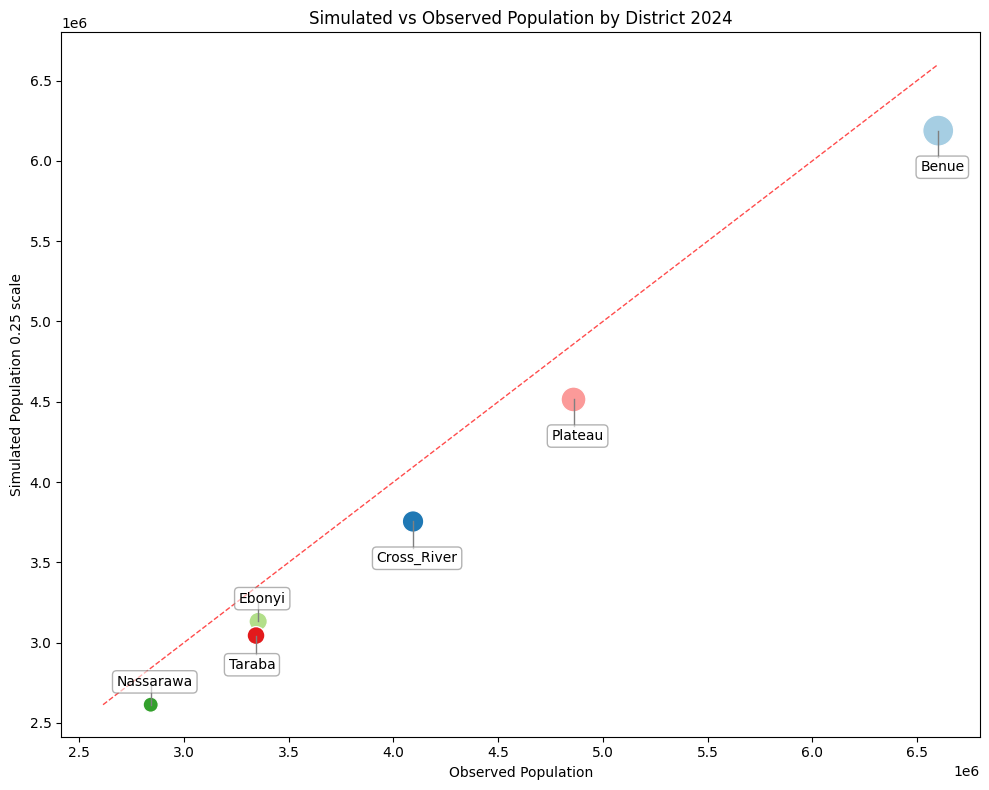

In [44]:
# ======================================================
# Figure 2: Simulated vs Observed Population by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d2 = compare_data[["population_obs", "mean_population_sim", "State"]].dropna(
    subset=["population_obs", "mean_population_sim"]
)

sns.scatterplot(
    data=d2,
    x="population_obs",
    y="mean_population_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

texts = d2["State"].astype(str).fillna("").tolist()
x = d2["population_obs"].to_numpy(dtype=float)
y = d2["mean_population_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=10,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.01,
    min_distance=0.01,
    max_distance=0.08,
    nbr_candidates=300,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

min_val = min(d2["population_obs"].min(), d2["mean_population_sim"].min())
max_val = max(d2["population_obs"].max(), d2["mean_population_sim"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1, color="red", alpha=0.7)

ax.set_title(f"Simulated vs Observed Population by District {calibration_year}")
ax.set_xlabel("Observed Population")
ax.set_ylabel(f"Simulated Population {population_scale_from_input_yml} scale")

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Population_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

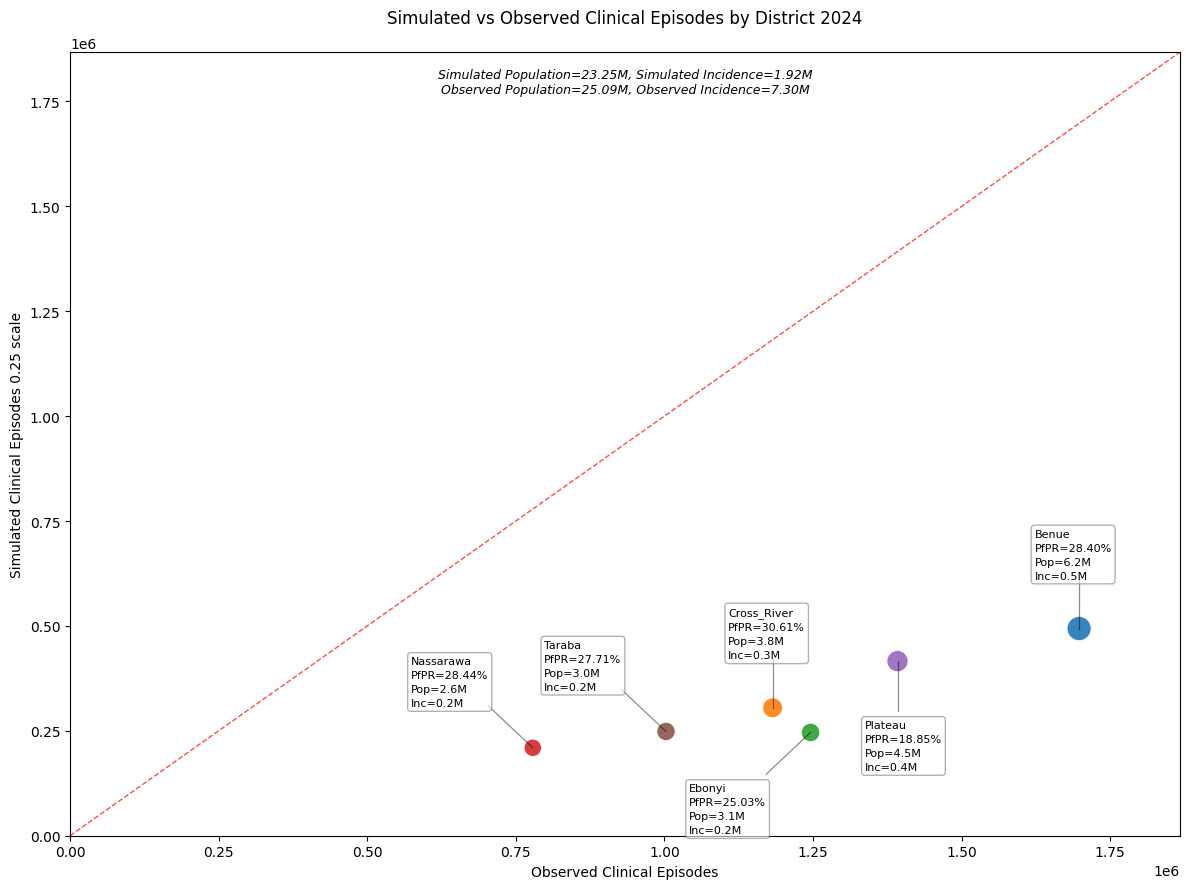

In [45]:
# ======================================================
# Figure 3: Simulated vs Observed Clinical Episodes by District
# ======================================================
fig, ax = plt.subplots(figsize=(12, 9))

d4 = compare_data[
    [
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "State",
        "mean_2_to_10_sim",
        "population_obs"
    ]
].dropna(
    subset=[
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "mean_2_to_10_sim",
        "population_obs"
    ]
).copy()

x = d4["annual_clinical_episodes_obs"].to_numpy(float)
# y = d4["mean_clinical_episodes_sim"].to_numpy(float)
y = d4["adjusted_mean_clinical_episodes_sim"].to_numpy(float)

pop = d4["mean_population_sim"].to_numpy(float)
sizes = (pop / pop.max()) * 250.0 + 50.0

total_pop_sim = d4["mean_population_sim"].sum()
# total_clinical_episodes_sim = d4["mean_clinical_episodes_sim"].sum()
total_clinical_episodes_sim = d4["adjusted_mean_clinical_episodes_sim"].sum()
total_pop_obs = d4["population_obs"].sum()
total_clinical_episodes_obs = d4["annual_clinical_episodes_obs"].sum()

texts = []
for _, row in d4.iterrows():
    name = str(row["State"])
    pfpr = row["mean_2_to_10_sim"]
    population = row["mean_population_sim"]
    # cases = row["mean_clinical_episodes_sim"]
    cases = row["adjusted_mean_clinical_episodes_sim"]
    label = f"{name}\nPfPR={pfpr*100:.2f}%\nPop={population/1e6:.1f}M\nInc={cases/1e6:.1f}M"
    texts.append(label)

districts = d4["State"].astype(str).tolist()
palette = sns.color_palette("tab10", n_colors=len(districts))
color_map = {name: palette[i] for i, name in enumerate(districts)}
colors = [color_map[name] for name in districts]

sc = ax.scatter(
    x, y,
    s=sizes,
    c=colors,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.6,
    zorder=2,
)

maxv = max(np.nanmax(x), np.nanmax(y)) * 1.10
ax.set_xlim(0, maxv)
ax.set_ylim(0, maxv)

linecolor = [(0, 0, 0, 0.45)] * len(x)

allocate(
    ax, x, y, texts,
    scatter_plot=sc,
    textsize=8,
    draw_lines=True,
    draw_all=True,
    linecolor=linecolor,
    linewidth=0.9,
    margin=0.03,
    min_distance=0.04,
    max_distance=0.38,
    nbr_candidates=5000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot(ax.get_xlim(), ax.get_ylim(), color="red", linestyle="--", linewidth=1, zorder=1, alpha=0.7)
ax.set_xlabel("Observed Clinical Episodes")
ax.set_ylabel(f"Simulated Clinical Episodes {population_scale_from_input_yml} scale")
ax.set_title(
    f"Simulated vs Observed Clinical Episodes by District {calibration_year}\n"
)

ax.text(
    0.5, 0.98,
    f"Simulated Population={total_pop_sim/1e6:.2f}M, Simulated Incidence={total_clinical_episodes_sim/1e6:.2f}M\n"
    f"Observed Population={total_pop_obs/1e6:.2f}M, Observed Incidence={total_clinical_episodes_obs/1e6:.2f}M",
    transform=ax.transAxes,
    fontsize=9, color="black", style="italic",
    ha="center", va="top"
)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Clinical_Episodes_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

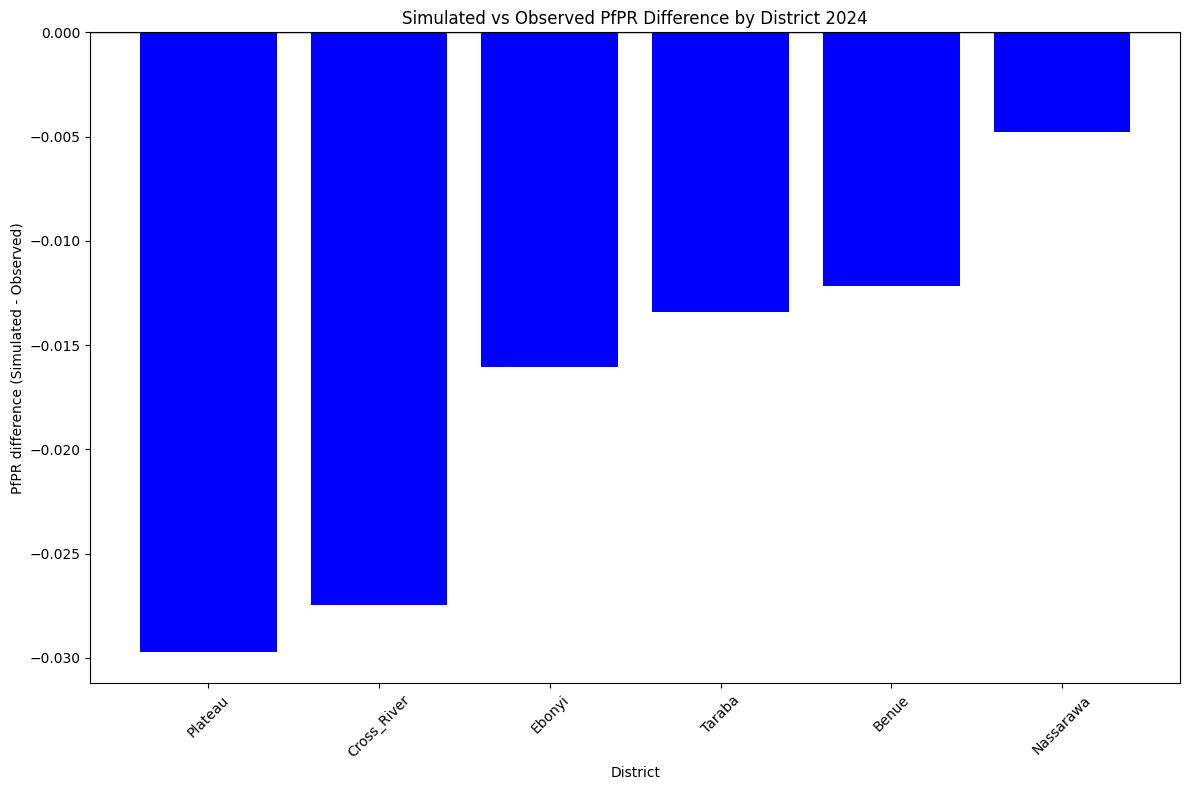

In [46]:
# ======================================================
# Figure 4: Simulated vs Observed PfPR difference by district
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8))

d3 = compare_data.copy()
d3["diff"] = d3["mean_2_to_10_sim"] - d3["mean_2_to_10_obs"]
d3 = d3.sort_values("diff")

colors = ["red" if d > 0 else "blue" for d in d3["diff"]]

ax.bar(d3["State"].astype(str), d3["diff"], color=colors)
ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("District")
ax.set_ylabel("PfPR difference (Simulated - Observed)")
ax.set_title(f"Simulated vs Observed PfPR Difference by District {calibration_year}")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_Difference_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()